In [1]:
from aqua.diagnostics import ssh_variability_compute, ssh_variability_plot
from aqua import Reader

/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# dataset_dict = {"catalog": "climatedt-o25.1-zarr", "model": "IFS-FESOM", "exp":"historical-1990", "source":"monthly-hpz10-oce2d"}
dataset_dict_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", "source":"daily-zarr"}

## Regrid data is also possible. Make sure to choose a correct Regridding method in the plotting function
# dataset_dict = {"catalog": "climatedt-phase1", "model": "IFS-NEMO", "exp":"historical-1990", "source":"ssh-IFS-NEMO-test", "regrid":"r025"}
# dataset_dict_ref = {"catalog": "obs", "model": "AVISO", "exp":"ssh-L4", "source":"ssh-AVISO-test", "regrid":"r025"}

In [37]:
test_reader = Reader(**dataset_dict_ref, regrid="r100")
test_data = test_reader.retrieve(var='zos', startdate="1990-01-01", enddate="1994-01-01")
test_data

2026-03-16 13:23:42 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-03-16 13:23:42 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data


<xarray.Dataset> Size: 3GB
Dimensions:  (time: 366, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-01 1993-01-02 ... 1994-01-01
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Data variables:
    zos      (time, lat, lon) float64 3GB dask.array<chunksize=(30, 720, 1440), meta=np.ndarray>
Attributes: (12/42)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         http://climate.copernicus.eu/c3s-user-se...
    creator_email:                   http://climate.copernicus.eu/c3s-user-se...
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               1993-01-01T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             1992-12-31T12:00:00Z
    title:                           DT merged two satellites Global Ocean Gr...

In [4]:
# from aqua import Reader
# dataset_dict = {"catalog": "climatedt-o25.1-zarr", "model": "IFS-NEMO", "exp":"historical-1990", "source":"monthly-hpz10-oce2d", "fix":True}
# reader = Reader(**dataset_dict)
# data = reader.retrieve(var="zos")

In [5]:
startdate="1990-01-01";enddate="1996-01-01"; startdate_ref="1990-01-01"; enddate_ref="1996-01-01";

In [8]:
# Intialize the SSH compute class for Reference data AVISO
ssh_dataset_ref = ssh_variability_compute(
                    **dataset_dict_ref,
                    var='zos',
                    startdate=startdate,
                    enddate=enddate,)

In [9]:
# Run the compute function and save as NetCDF
ssh_dataset_ref.run()

2026-03-16 12:30:07 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-03-16 12:30:07 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data
/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [4]:
# Initialize the SSH plot class
plot_class = ssh_variability_plot()

In [5]:
# It is important to choose a correct 'tgt_grid_name' so that the data aligns with land mask
# tgt_grid_name = "r1440x721"
tgt_grid_name = "r1440x720" 

2026-03-16 12:31:06 :: Regridder :: WARNING  -> No cfg_grid_dict dictionary provided, only CDO grid names can be used.
2026-03-16 12:31:06 :: Regridder :: WARNING  -> Weights block not found in the configuration file, using fallback naming scheme.
2026-03-16 12:31:18 :: Regridder :: ERROR    -> Regridder for vertical coordinate 2d not found.
2026-03-16 12:31:18 :: Regridder :: ERROR    -> Cannot regrid variable zos


(<Figure size 1100x850 with 2 Axes>,
 <GeoAxes: title={'center': 'SSH Variability of Absolute dynamic topography for obs AVISO ssh-L4 1990-01-01-1996-01-01'}, xlabel='Longitude', ylabel='Latitude'>)

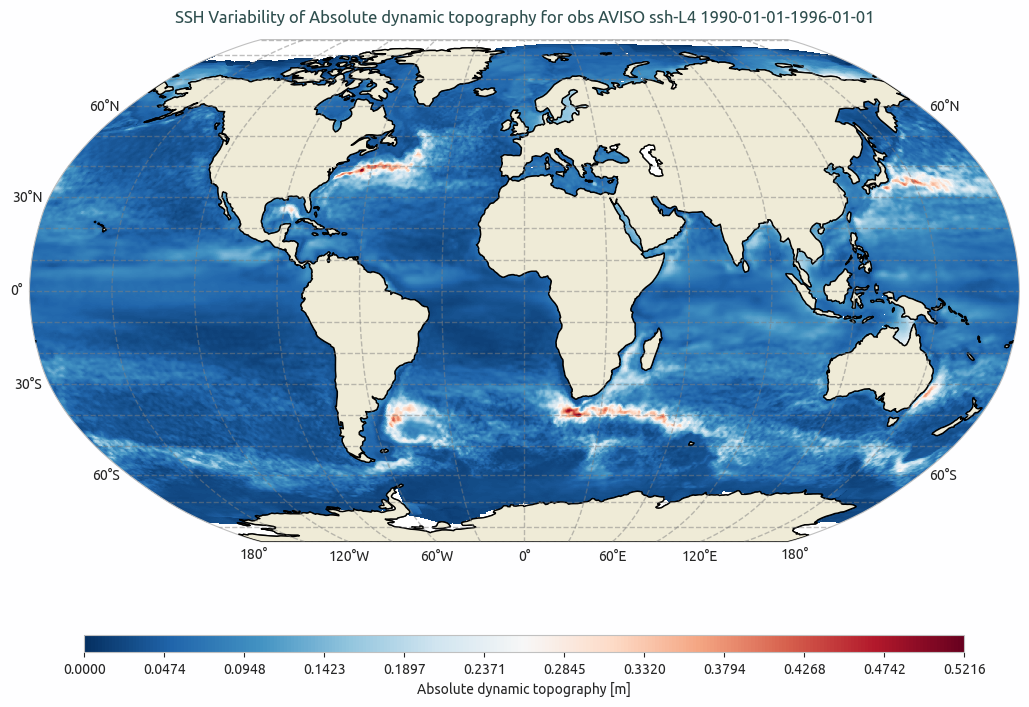

In [13]:
# Plot SSH for reference dataset 
# It is important to choose a correct 'tgt_grid_name' so that the data aligns with land mask
plot_dataset_ref = {"catalog": "obs", "model": "AVISO", "exp":"ssh-L4", "tgt_grid_name":tgt_grid_name,}
plot_class.plot(dataset_std=ssh_dataset_ref.data_std, **plot_dataset_ref, startdate=startdate, enddate=enddate,)

2026-03-16 12:33:13 :: Regridder :: WARNING  -> No cfg_grid_dict dictionary provided, only CDO grid names can be used.
2026-03-16 12:33:13 :: Regridder :: WARNING  -> Weights block not found in the configuration file, using fallback naming scheme.
2026-03-16 12:33:13 :: Regridder :: ERROR    -> Regridder for vertical coordinate 2d not found.
2026-03-16 12:33:13 :: Regridder :: ERROR    -> Cannot regrid variable zos


(<Figure size 1100x850 with 2 Axes>,
 <GeoAxes: title={'center': 'SSH Variability of Absolute dynamic topography [Agulhas] for obs AVISO ssh-L4 1990-01-01-1996-01-01'}, xlabel='Longitude', ylabel='Latitude'>)

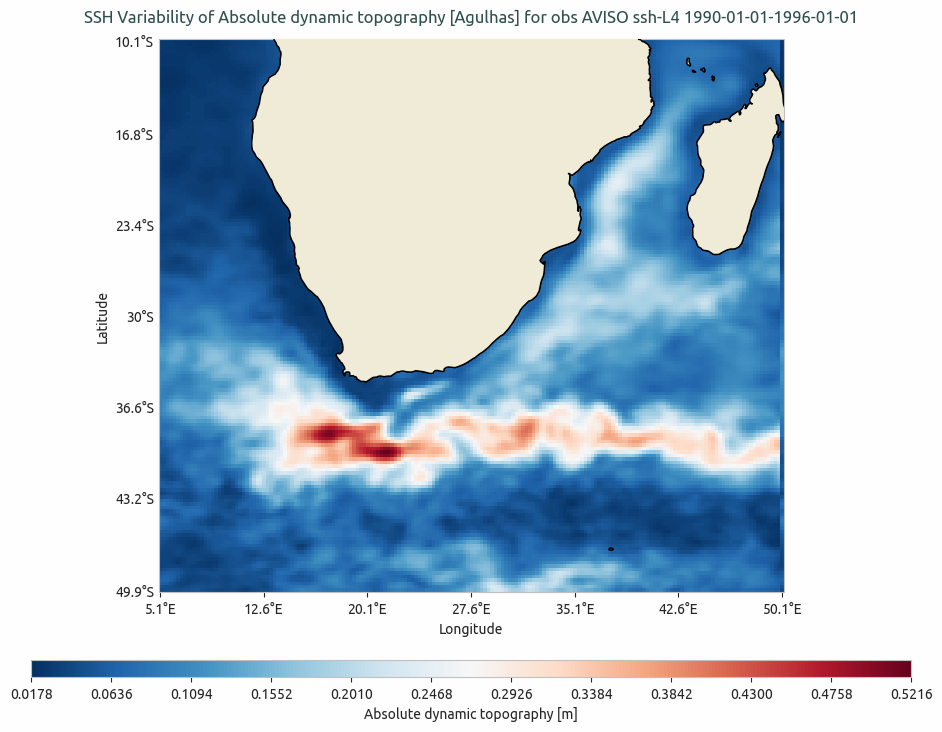

In [15]:
# Plot the sub region for Reference data
# It is important to choose a correct 'tgt_grid_name' so that the data aligns with land mask
sub_region_dataset_ref = {"catalog": "obs", "model": "AVISO", "exp":"ssh-L4", 'region': 'Agulhas', 'lon_limits': [5, 50], 'lat_limits': [-10, -50], 'proj': 'plate_carree', 'proj_params': {}, "tgt_grid_name":tgt_grid_name,}
plot_class.plot(dataset_std=ssh_dataset_ref.data_std, **sub_region_dataset_ref, startdate=startdate, enddate=enddate,)

In [40]:
#######################################import xarray as xr
import numpy as np
import xarray as xr
# Assuming 'ds' is your xarray.Dataset and 'my_variable' is your 3D data array
da = test_data

In [41]:
# 1. Initialize the Welford State for the ENTIRE dataset
# Use the first spatial slice as a template for our state arrays (lat, lon)
template = da.isel(time=0).drop_vars('time')

k = 0
m = xr.zeros_like(template, dtype=float)
s = xr.zeros_like(template, dtype=float)

# Track the starting month and year
current_month = da.time.dt.month[0].values
current_year = da.time.dt.year[0].values

# 2. One-Pass Continuous Loop
for t_idx in range(da.sizes['time']):
    # Read the current time step
    step_data = da.isel(time=t_idx)
    step_month = step_data.time.dt.month.values
    step_year = step_data.time.dt.year.values
    
    # === THE CHECKPOINT TRIGGER ===
    # If we crossed into a new month, snapshot the running variance
    if step_month != current_month or step_year != current_year:
        
        if k > 1:
            # Calculate the running sample variance up to this point
            running_variance = s / (k - 1)
            
            # Tag with metadata
            running_variance = running_variance.assign_coords(
                checkpoint_month=current_month, 
                checkpoint_year=current_year
            )
            
            # --> SAVE CHECKPOINT TO DISK (Highly recommended for large data)
            filename = f"running_variance_upto_{current_year}_{current_month:02d}.nc"
            running_variance.to_netcdf(filename)
            print(f"Checkpointed running variance up to end of {current_year}-{current_month:02d}")
            
        # CRITICAL DIFFERENCE: We DO NOT reset k, m, and s here. 
        # We just update the time trackers and keep accumulating.
        current_month = step_month
        current_year = step_year

    # === THE WELFORD UPDATE ===
    x = step_data.drop_vars('time')
    k += 1
    
    old_m = m.copy() # Must copy to prevent reference overwriting
    m = old_m + (x - old_m) / k
    s = s + (x - old_m) * (x - m)

# 3. Final Total 2D Variance
# After the loop finishes, the variables hold the state for the entire time series
if k > 1:
    total_variance = s / (k - 1)
else:
    total_variance = xr.full_like(s, np.nan)

# Optional: Save the final total variance
total_variance.to_netcdf("final_total_2D_variance.nc")

print("Processing complete. Final Total Variance array shape:", total_variance.shape)

Checkpointed running variance up to end of 1993-01
Checkpointed running variance up to end of 1993-02
Checkpointed running variance up to end of 1993-03
Checkpointed running variance up to end of 1993-04
Checkpointed running variance up to end of 1993-05
Checkpointed running variance up to end of 1993-06
Checkpointed running variance up to end of 1993-07
Checkpointed running variance up to end of 1993-08
Checkpointed running variance up to end of 1993-09
Checkpointed running variance up to end of 1993-10
Checkpointed running variance up to end of 1993-11
Checkpointed running variance up to end of 1993-12


AttributeError: 'Dataset' object has no attribute 'shape'

In [46]:
d0 = xr.open_dataset('running_variance_upto_1993_12.nc')
d1 = xr.open_dataset('final_total_2D_variance.nc')
d = d1 - d0

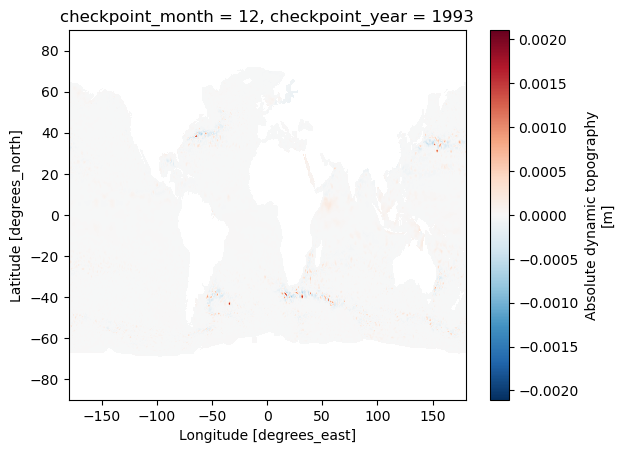

In [47]:
d['zos'].plot()

2025-11-18 02:05:24 :: Regridder :: WARNING  -> No cfg_grid_dict dictionary provided, only CDO grid names can be used.
2025-11-18 02:05:24 :: Regridder :: WARNING  -> Weights block not found in the configuration file, using fallback naming scheme.
2025-11-18 02:05:25 :: Regridder :: WARNING  -> No cfg_grid_dict dictionary provided, only CDO grid names can be used.
2025-11-18 02:05:25 :: Regridder :: WARNING  -> Weights block not found in the configuration file, using fallback naming scheme.


(<Figure size 1100x850 with 2 Axes>,
 <GeoAxes: title={'center': 'The difference of the SSH Variability of Sea surface height for IFS-NEMO historical-1990 (1994-01-01-1994-01-04) and, reference obs AVISO and ssh-L4 (1994-01-01-1994-01-04) Agulhas '}, xlabel='Longitude', ylabel='Latitude'>)

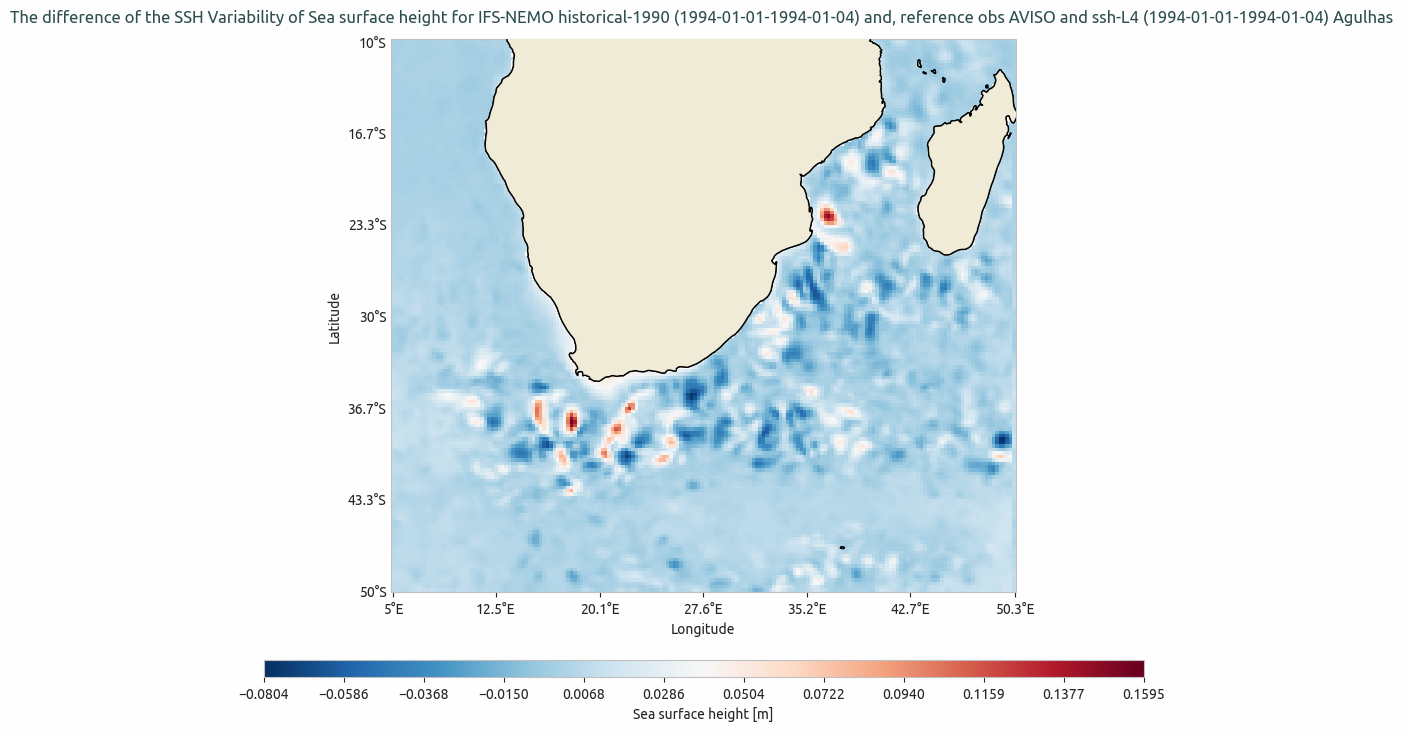

In [14]:
# Plot the diference of sub region for model dataset and reference dataset AVISO
time_intervals = {"startdate": "1994-01-01", "enddate": "1994-01-04", "startdate_ref": "1994-01-01", "enddate_ref": "1994-01-04"}
region_selection = {'region': 'Agulhas', 'lon_limits': [5, 50], 'lat_limits': [-10, -50], 'proj': 'plate_carree', 'proj_params': {},}
_dataset_ref = {"catalog_ref": "obs", "model_ref": "AVISO", "exp_ref":"ssh-L4",}
_dataset = {"catalog": "climatedt-phase1", "model": "IFS-NEMO", "exp":"historical-1990",}
plot_class.plot_diff(dataset_std=ssh_dataset.data_std, dataset_std_ref=ssh_dataset_ref.data_std, tgt_grid_name=tgt_grid_name, **_dataset, **_dataset_ref, **region_selection, **time_intervals)